# **NOTEBOOK 5: Advanced Models**

In [26]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error, median_absolute_error
import seaborn as sns
from matplotlib import pyplot as plt
import geopandas as gpd
from geopandas import GeoDataFrame
from shapely.geometry import Point

## Load Dataset

In [2]:
def load_dataset():
    file_path = Path.home() / 'Documents/IDX Internship/Raw Data'
    
    # all 30 datasets
    files = [
        file_path / 'CRMLSSold20220101_20231231_filled.csv', file_path / 'CRMLSSold202401_filled.csv',
        file_path / 'CRMLSSold202402_filled.csv', file_path / 'CRMLSSold202403_filled.csv',
        file_path / 'CRMLSSold202404_filled.csv', file_path / 'CRMLSSold202405_filled.csv',
        file_path / 'CRMLSSold202406_filled.csv', file_path / 'CRMLSSold202407_filled.csv',
        file_path / 'CRMLSSold202408.csv', file_path / 'CRMLSSold202409.csv',
        file_path / 'CRMLSSold202410.csv', file_path / 'CRMLSSold202411.csv',
        file_path / 'CRMLSSold202412.csv', file_path / 'CRMLSSold202501_filled.csv',
        file_path / 'CRMLSSold202502.csv', file_path / 'CRMLSSold202503.csv',
        file_path / 'CRMLSSold202504.csv', file_path / 'CRMLSSold202505.csv',
        file_path / 'CRMLSSold202506.csv', file_path / 'CRMLSSold202507.csv',
        file_path / 'CRMLSSold202508.csv', file_path / 'CRMLSSold202509.csv',
        file_path / 'CRMLSSold202510.csv', file_path / 'CRMLSSold202511.csv',
        file_path / 'CRMLSSold202512.csv', file_path / 'CRMLSSold202601.csv',
        file_path / 'CRMLSSold202602.csv', file_path / 'CRMLSSold202603.csv',
        file_path / 'CRMLSSold202604.csv', file_path / 'CRMLSSold202605.csv',
    ]
    
    # dtype to str to handle mixed value types for some columns
    data_dfs = [pd.read_csv(f, dtype={'WaterfrontYN': str, 'PostalCode': str, 'latfilled': str, 'lonfilled': str,
                                      'ElementarySchool': str, 'BuilderName': str, 'CoBuyerAgentFirstName': str,
                                      'PoolPrivateYN': str}) for f in files]
    df = pd.concat(data_dfs, ignore_index=True)

    return df

In [3]:
init_df = load_dataset()
init_df.head()

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,BuyerAgentAOR,ListAgentAOR
0,"Carpet,Wood",True,NaN,NaN,True,98000.0,556366533,michellefsellsoc@gmail.com,2022-02-25,95000.0,...,0.0,ABC Unified,92708,0.0,NaN,NaN,False,False,NaN,NaN
1,NaN,False,NaN,NaN,False,1200.0,556366530,dineshcalre@gmail.com,2022-02-19,1200.0,...,1.0,Apple Valley Unified,92308,0.0,43000.0,NaN,False,False,NaN,NaN
2,NaN,True,NaN,NaN,False,1100000.0,556366044,cindydavishomes@gmail.com,2022-04-15,1100000.0,...,1.0,Solana Beach,92075,370.0,NaN,NaN,False,False,NaN,NaN
3,NaN,True,NaN,NaN,False,2499999.0,556365765,bryanmeathe@gmail.com,2022-01-04,2499999.0,...,2.0,Carlsbad Unified,92008,140.0,13376.0,NaN,False,False,NaN,NaN
4,"Carpet,Tile",NaN,NaN,NaN,NaN,598888.0,556365290,steven@westsideres.com,2022-01-12,640000.0,...,1.0,Other,95111,300.0,2738.0,NaN,False,False,NaN,NaN


## Data Preprocessing

In [34]:
def preprocessing(loc_features=False):

    # load dataset
    df = load_dataset()
    
    # restrict analysis to residential and single family
    df = df[
        (df['PropertyType'] == 'Residential') &
        (df['PropertySubType'] == 'SingleFamilyResidence')].copy()

    # convert CloseDate to datetime dtype
    df['CloseDate'] = pd.to_datetime(df['CloseDate'])


    preprocessed_df = df.copy()
    

    ####################
    ### drop columns ###
    ####################
    
    # drop columns not known at prediction time
    drop_cols = ['ListPrice', 'DaysOnMarket', 'OriginalListPrice']
    preprocessed_df = preprocessed_df.drop(columns=drop_cols)

    # count missing values
    missing = pd.DataFrame({
        'Total Missing Values': preprocessed_df.isnull().sum(),
        'Proportion Missing': preprocessed_df.isnull().mean()
    })

    # drop column if null rate above 50%
    threshold = 0.5
    null_50 = missing[missing['Proportion Missing'] > threshold].index.tolist()
    preprocessed_df = preprocessed_df.drop(columns=null_50)

    # drop columns with no plausible relationship to ClosePrice
    unrelated = ['ContractStatusChangeDate', 'MlsStatus', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'ListingId',
                 'PurchaseContractDate', 'ListingContractDate', 'ListAgentEmail', 'ListOfficeName', 'BuyerOfficeName',
                 'ListingKey', 'ListingKeyNumeric', 'ListAgentFirstName', 'ListAgentLastName', 'StreetNumberNumeric',
                 'ListAgentFullName', 'BuyerAgentMlsId', 'BuyerOfficeAOR', 'BuyerAgentAOR', 'ListAgentAOR',
                 'UnparsedAddress']
    preprocessed_df = preprocessed_df.drop(columns=unrelated)

    # drop location variables (redundant due to Latitude and Longitude)
    preprocessed_df = preprocessed_df.drop(columns=['MLSAreaMajor', 'PostalCode'])
    

    ###################################
    ### convert unreasonable values ###
    ###################################

    # convert impossible coordinates to NaN
    invalid_coords = (
        (preprocessed_df['Latitude'] < -90) | (preprocessed_df['Latitude'] > 90) |
        (preprocessed_df['Longitude'] < -180) | (preprocessed_df['Longitude'] > 180) |
        (preprocessed_df['Latitude'] == 0) | (preprocessed_df['Longitude'] == 0)
    )
    preprocessed_df.loc[invalid_coords, ['Latitude','Longitude']] = np.nan

    # remove LivingArea values of 0
    preprocessed_df.loc[preprocessed_df['LivingArea'] <= 0, 'LivingArea'] = np.nan

    # remove ParkingTotal values less than 0 and greater than 100
    preprocessed_df.loc[preprocessed_df['ParkingTotal'] < 0, 'ParkingTotal'] = np.nan
    preprocessed_df.loc[preprocessed_df['ParkingTotal'] > 100, 'ParkingTotal'] = np.nan


    # drop rows with missing values for target variable and other important features with very little null values
    preprocessed_df = preprocessed_df.dropna(subset=['ClosePrice', 'LivingArea'])

    # drop properties not in California
    preprocessed_df = preprocessed_df[preprocessed_df['StateOrProvince'] == 'CA'].copy()
    preprocessed_df = preprocessed_df.drop(columns=['StateOrProvince'])
    

    #######################
    ### fill NaN values ###
    #######################

    # fill values with less than 50% null rate
    # sentinel fill
    preprocessed_df['ParkingTotal'] = preprocessed_df['ParkingTotal'].fillna(0)
    preprocessed_df['GarageSpaces'] = preprocessed_df['GarageSpaces'].fillna(0)
    preprocessed_df['MainLevelBedrooms'] = preprocessed_df['MainLevelBedrooms'].fillna(0)
    
    # median fill
    for col in ['LotSizeSquareFeet', 'YearBuilt', 'Stories', 'Latitude', 'Longitude', 'BedroomsTotal',
                'BathroomsTotalInteger']:
        preprocessed_df[col] = preprocessed_df[col].fillna(preprocessed_df[col].median())

    # create binary has_hoa feature from AssociationFee
    preprocessed_df['AssociationFee'] = preprocessed_df['AssociationFee'].fillna(0)
    preprocessed_df["has_hoa"] = (preprocessed_df["AssociationFee"] > 0).astype(int)

    # create binary has_garage feature from GarageSpaces
    preprocessed_df['GarageSpaces'] = preprocessed_df['GarageSpaces'].fillna(0)
    preprocessed_df['has_garage'] = (preprocessed_df['GarageSpaces'] > 0).astype(int)
    preprocessed_df = preprocessed_df.drop(columns=['GarageSpaces'])
    
    # drop features with zero variance
    preprocessed_df = preprocessed_df.drop(columns=['PropertyType', 'PropertySubType'])

    # keep only one area column (LotSizeSquareFeet)
    preprocessed_df = preprocessed_df.drop(columns=['LotSizeArea', 'LotSizeAcres'])

    # fill null values for certain bool values with False
    for col in ['ViewYN', 'PoolPrivateYN', 'AttachedGarageYN', 'FireplaceYN', 'NewConstructionYN']:
        preprocessed_df[col] = preprocessed_df[col].astype(bool)
        preprocessed_df[col] = preprocessed_df[col].fillna(False).astype(int)

    # fill missing values for certain categorical variables with 'Unknown'
    for col in ['Flooring', 'HighSchoolDistrict', 'Levels', 'City']:
        preprocessed_df[col] = preprocessed_df[col].fillna('Unknown')
    
    # fill missing value for CountyOrParish with mode
    preprocessed_df['CountyOrParish'] = preprocessed_df['CountyOrParish'].fillna(
        preprocessed_df['CountyOrParish'].mode()[0]
    )


    ####################################
    ### encode categorical variables ###
    ####################################

    # multi-label encode Flooring feature
    preprocessed_df['Flooring_SeeRemarks'] = (preprocessed_df['Flooring'].str.contains('SeeRemarks').astype(int))
    preprocessed_df['Flooring'] = (preprocessed_df['Flooring'].str.replace('SeeRemarks,?', '', regex=True))
    flooring_dummies = (preprocessed_df['Flooring'].str.get_dummies(sep=','))
    
    preprocessed_df = pd.concat(
        [preprocessed_df.drop(columns=['Flooring']), flooring_dummies.add_prefix('Flooring_')], axis=1)

    # multi-label encode Levels
    # create multi-label dummy variables
    levels_dummies = (preprocessed_df['Levels'].str.get_dummies(sep=','))
    levels_dummies = levels_dummies.add_prefix('Levels_') # add prefix
    
    preprocessed_df = pd.concat([preprocessed_df.drop(columns=['Levels']),levels_dummies],axis=1)


    if loc_features == True:
        # one-hot encode CountyOrParish
        preprocessed_df['CountyOrParish'] = (preprocessed_df['CountyOrParish'].str.title()) # standard capitalization
        preprocessed_df['CountyOrParish'] = (preprocessed_df['CountyOrParish'].replace(
            ['Foreign Country', 'Other County', 'Other State', 'Other'], 'Other')) # replace non-counties with 'Other'
        preprocessed_df = pd.get_dummies(preprocessed_df, columns=['CountyOrParish'], drop_first=True, dtype='int8')
    
        # group cities with less than 500 entires and one-hot encode City
        city_counts = preprocessed_df['City'].value_counts()
        rare_cities = city_counts[city_counts < 500].index
        preprocessed_df['City'] = (preprocessed_df['City'].replace(rare_cities, 'Other'))
        preprocessed_df = pd.get_dummies(preprocessed_df, columns=['City'], drop_first=True, dtype='int8')

    else:
        preprocessed_df = preprocessed_df.drop(columns=['CountyOrParish', 'City'])


    ###########################
    ### feature engineering ###
    ###########################

    ## UnifiedSchoolDistrict ##
    districts = gpd.read_file(
        Path.home() / 'Documents/IDX Internship/Resources/CaliforniaSchoolDistricts.geojson'
    )
    # filter unified districts
    districts = districts[districts['DistrictType'] == 'Unified'].copy()
    # convert properties to geographic point
    properties = gpd.GeoDataFrame(
        preprocessed_df,
        geometry=gpd.points_from_xy(preprocessed_df['Longitude'], preprocessed_df['Latitude']),
        crs='EPSG:4326'
    )
    districts = districts.to_crs(properties.crs)
    # perform spatial join
    properties = gpd.sjoin(properties, districts, how='left', predicate='within')
    preprocessed_df['UnifiedSchoolDistrict'] = properties['DistrictName']
    # one-hot encode new school districts feature
    preprocessed_df = pd.get_dummies(preprocessed_df,
                                columns=['UnifiedSchoolDistrict'],
                                drop_first=True,
                                dtype='int8',
                                prefix='',
                                prefix_sep='')
    
    # drop old HighSchoolDistrict column
    preprocessed_df = preprocessed_df.drop(columns=['HighSchoolDistrict'])


    ## PropertyAge ##
    # subtract year built from close date
    preprocessed_df['CloseDate'] = pd.to_datetime(preprocessed_df['CloseDate'])
    preprocessed_df['PropertyAge'] = (preprocessed_df['CloseDate'].dt.year - preprocessed_df['YearBuilt'])
    preprocessed_df = preprocessed_df.drop(columns=['YearBuilt'])


    ## Bed/Bath Ratio ##
    # divide bedrooms by bathrooms
    preprocessed_df['BedBathRatio'] = (preprocessed_df['BedroomsTotal'] / preprocessed_df['BathroomsTotalInteger'])
    # replace division by zero values with 0
    preprocessed_df['BedBathRatio'] = (preprocessed_df['BedBathRatio'].replace([np.inf, -np.inf], np.nan).fillna(0))
    

    return preprocessed_df


In [35]:
preprocessed_df = preprocessing()
preprocessed_df.shape

(398764, 366)

## Train/Test Split

In [30]:
def train_test_split(df, train_months):

    df = df.copy()

    # ensure datetime
    df['CloseDate'] = pd.to_datetime(df['CloseDate'])

    # get monthly periods
    df['CloseMonth'] = df['CloseDate'].dt.to_period('M')

    # most recent month becomes test
    latest_month = df['CloseMonth'].max()

    test_df = df[df['CloseMonth'] == latest_month]

    # X months immediately before test month
    train_start = latest_month - train_months

    train_df = df[(df['CloseMonth'] < latest_month) & (df['CloseMonth'] >= train_start)]

    # remove date columns
    train_df = train_df.drop(columns=['CloseDate', 'CloseMonth'])

    test_df = test_df.drop(columns=['CloseDate', 'CloseMonth'])

    # separate target
    X_train = train_df.drop(columns=['ClosePrice'])
    y_train = train_df['ClosePrice']

    X_test = test_df.drop(columns=['ClosePrice'])
    y_test = test_df['ClosePrice']

    return X_train, X_test, y_train, y_test

## Filter Outliers/Extremes

In [73]:
def data_filter(X_train,
           X_test,
           y_train,
           y_test,
           lower_threshold=0.005,
           upper_threshold=0.995):
    
    # compute ClosePrice thresholds from training set only
    lower = y_train.quantile(lower_threshold)
    upper = y_train.quantile(upper_threshold)
    
    # apply thresholds to train and test
    train_filter = y_train.between(lower, upper)
    test_filter = y_test.between(lower, upper)
    
    X_train = X_train[train_filter]
    y_train = y_train[train_filter]
    X_test = X_test[test_filter]
    y_test = y_test[test_filter]

    return X_train, X_test, y_train, y_test

## Evaluation Metrics

In [31]:
# define MdAPE
def mdape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    ape = np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]) * 100
    return np.median(ape)

# define metrics function
def metrics(y_true, y_pred):
      return {
          'R2': f"{r2_score(y_true, y_pred):.4f}",
          'MAE': f"${mean_absolute_error(y_true, y_pred):.2f}",
          'RMSE': f"${root_mean_squared_error(y_true, y_pred):.2f}",
          'MedianAbsoluteError': f"${median_absolute_error(y_true, y_pred):.2f}",
          'MDAPE': f"{mdape(y_true, y_pred):.2f}%"
      }

## Baseline Model
- Train linear regression model with and without additional location features
    - CountyOrParish
    - City
- Determine better preprocessed dataset

In [62]:
loc_df = preprocessing(loc_features=True)
no_loc_df = preprocessing(loc_features=False)

X_train_loc, X_test_loc, y_train_loc, y_test_loc = train_test_split(loc_df, 30)
X_train_no_loc, X_test_no_loc, y_train_no_loc, y_test_no_loc = train_test_split(no_loc_df, 30)

lower_loc = y_train_loc.quantile(0.005)
upper_loc = y_train_loc.quantile(0.995)
lower_no_loc = y_train_no_loc.quantile(0.005)
upper_no_loc = y_train_no_loc.quantile(0.995)

train_filter_loc = y_train_loc.between(lower_loc, upper_loc)
test_filter_loc = y_test_loc.between(lower_loc, upper_loc)
train_filter_no_loc = y_train_no_loc.between(lower_no_loc, upper_no_loc)
test_filter_no_loc = y_test_no_loc.between(lower_no_loc, upper_no_loc)

X_train_loc = X_train_loc[train_filter_loc]
y_train_loc = y_train_loc[train_filter_loc]
X_test_loc = X_test_loc[test_filter_loc]
y_test_loc = y_test_loc[test_filter_loc]

X_train_no_loc = X_train_no_loc[train_filter_no_loc]
y_train_no_loc = y_train_no_loc[train_filter_no_loc]
X_test_no_loc = X_test_no_loc[test_filter_no_loc]
y_test_no_loc = y_test_no_loc[test_filter_no_loc]

In [63]:
# without additional location features
loc_lr = LinearRegression()
loc_lr.fit(X_train_loc, y_train_loc)
loc_pred = loc_lr.predict(X_test_loc)

# without additional location features
no_loc_lr = LinearRegression()
no_loc_lr.fit(X_train, y_train)
no_loc_pred = no_loc_lr.predict(X_test)

loc_metrics = metrics(y_test_loc, loc_pred)
no_loc_metrics = metrics(y_test, no_loc_pred)

baseline_res = pd.DataFrame(
    [loc_metrics, no_loc_metrics],
    index=['Linear Regression (with loc features)', 'Linear Regression (without loc features)']
)

baseline_res

,R2,MAE,RMSE,MedianAbsoluteError,MDAPE
Linear Regression (with loc features),0.7855,$276432.90,$451337.67,$179265.56,18.54%
Linear Regression (without loc features),0.6833,$347113.84,$548477.69,$227487.18,23.43%


## Save Preprocessed Dataset (With Location Features)

In [65]:
preprocessed_df = preprocessing(loc_features=True)
preprocessed_df.to_csv('preprocessed_data.csv', index=False)

In [66]:
preprocessed_df.head()

,ViewYN,PoolPrivateYN,CloseDate,ClosePrice,Latitude,Longitude,LivingArea,AttachedGarageYN,ParkingTotal,BathroomsTotalInteger,...,Windsor Unified,Winters Joint Unified,Wiseburn Unified,Woodlake Unified,Woodland Joint Unified,Yosemite Unified,Yuba City Unified,Yucaipa-Calimesa Joint Unified,PropertyAge,BedBathRatio
3,1,1,2022-01-04,2499999.0,33.147270,-117.340604,2645.0,1,2.0,4.0,...,0,0,0,0,0,0,0,0,6.0,1.0
6,1,1,2022-01-10,640000.0,34.235979,-117.202269,2070.0,1,1.0,3.0,...,0,0,0,0,0,0,0,0,15.0,1.0
7,0,1,2022-03-23,438000.0,34.114130,-117.442493,1174.0,1,2.0,2.0,...,0,0,0,0,0,0,0,0,62.0,1.5
12,1,1,2022-01-10,615000.0,33.783767,-116.447280,1996.0,0,4.0,2.0,...,0,0,0,0,0,0,0,0,17.0,1.0
14,1,1,2022-01-19,399990.0,39.767729,-121.586400,1422.0,1,2.0,2.0,...,0,0,0,0,0,0,0,0,1.0,1.5


In [68]:
df = pd.read_csv('preprocessed_data.csv')
df.head()

,ViewYN,PoolPrivateYN,CloseDate,ClosePrice,Latitude,Longitude,LivingArea,AttachedGarageYN,ParkingTotal,BathroomsTotalInteger,...,Windsor Unified,Winters Joint Unified,Wiseburn Unified,Woodlake Unified,Woodland Joint Unified,Yosemite Unified,Yuba City Unified,Yucaipa-Calimesa Joint Unified,PropertyAge,BedBathRatio
0,1,1,2022-01-04,2499999.0,33.147270,-117.340604,2645.0,1,2.0,4.0,...,0,0,0,0,0,0,0,0,6.0,1.0
1,1,1,2022-01-10,640000.0,34.235979,-117.202269,2070.0,1,1.0,3.0,...,0,0,0,0,0,0,0,0,15.0,1.0
2,0,1,2022-03-23,438000.0,34.114130,-117.442493,1174.0,1,2.0,2.0,...,0,0,0,0,0,0,0,0,62.0,1.5
3,1,1,2022-01-10,615000.0,33.783767,-116.447280,1996.0,0,4.0,2.0,...,0,0,0,0,0,0,0,0,17.0,1.0
4,1,1,2022-01-19,399990.0,39.767729,-121.586400,1422.0,1,2.0,2.0,...,0,0,0,0,0,0,0,0,1.0,1.5


## Train Test Split

In [75]:
X = 30
X_train, X_test, y_train, y_test = train_test_split(df, X)
X_train, X_test, y_train, y_test = data_filter(X_train,
                                               X_test,
                                               y_train,
                                               y_test,
                                               lower_threshold=0.005,
                                               upper_threshold=0.995)

In [76]:
X_train.head()

,ViewYN,PoolPrivateYN,Latitude,Longitude,LivingArea,AttachedGarageYN,ParkingTotal,BathroomsTotalInteger,BedroomsTotal,FireplaceYN,...,Windsor Unified,Winters Joint Unified,Wiseburn Unified,Woodlake Unified,Woodland Joint Unified,Yosemite Unified,Yuba City Unified,Yucaipa-Calimesa Joint Unified,PropertyAge,BedBathRatio
3748,0,1,33.941807,-118.239928,1350.0,0,2.0,2.0,4.0,0,...,0,0,0,0,0,0,0,0,49.0,2.000000
4957,0,1,32.659210,-117.097531,1974.0,1,4.0,4.0,4.0,0,...,0,0,0,0,0,0,0,0,0.0,1.000000
4958,0,1,32.659251,-117.097312,1974.0,1,2.0,4.0,4.0,0,...,0,0,0,0,0,0,0,0,0.0,1.000000
4985,1,1,34.534363,-117.960529,2400.0,1,2.0,3.0,4.0,0,...,0,0,0,0,0,0,0,0,16.0,1.333333
5483,1,1,33.524038,-117.023755,5256.0,1,5.0,7.0,6.0,1,...,0,0,0,0,0,0,0,0,1.0,0.857143


## Install XGBoost

In [28]:
# %pip install xgboost

In [77]:
from xgboost import XGBRegressor

## XGBoost Regressor

In [78]:
# baseline XGBoost
xgb = XGBRegressor(random_state=123, n_estimators=100)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

xgb_metrics = metrics(y_test, xgb_pred)

print(xgb_metrics)

{'R2': '0.8626', 'MAE': '$201304.65', 'RMSE': '$361265.52', 'MedianAbsoluteError': '$107817.00', 'MDAPE': '11.77%'}


In [92]:
# experiment to find optimal hyperparameters
xgb_results = []

for depth in [3, 5, 7]:
    for lr in [0.05, 0.1, 0.2]:
        for estimators in [100, 200, 300]:

            # XGBoost model
            current_model = XGBRegressor(
                random_state=123,
                max_depth=depth,
                learning_rate=lr,
                n_estimators=estimators
            )
            
            current_model.fit(X_train, y_train)
            pred = current_model.predict(X_test)
            m = metrics(y_test, pred)
    
            # update results
            current_result = {
                'depth': depth,
                'learning_rate': lr,
                'n_estimators': estimators
            }
            
            current_result.update(m)
            xgb_results.append(current_result)


In [93]:
xgb_results = pd.DataFrame(xgb_results)
xgb_results.sort_values(by=['R2', 'MDAPE'], ascending=False).head()

,depth,learning_rate,n_estimators,R2,MAE,RMSE,MedianAbsoluteError,MDAPE
26,7,0.2,300,0.8923,$171740.41,$319914.62,$86150.62,9.55%
25,7,0.2,200,0.8861,$177971.25,$328958.78,$90573.69,10.01%
23,7,0.1,300,0.8831,$180868.46,$333209.16,$92784.00,10.17%
17,5,0.2,300,0.8772,$185544.04,$341533.06,$95309.75,10.49%
22,7,0.1,200,0.8757,$189351.84,$343558.92,$99051.00,10.84%


In [97]:
# additional hyperparameter tuning
xgb_new_results = []

for depth in [7, 8, 9, 10]:
    for estimators in [200, 300, 400, 500]:

        # XGBoost model
        current_model = XGBRegressor(
            random_state=123,
            max_depth=depth,
            learning_rate=0.2,
            n_estimators=estimators
        )
        
        current_model.fit(X_train, y_train)
        pred = current_model.predict(X_test)
        m = metrics(y_test, pred)
    
        # update results
        current_result = {
            'depth': depth,
            'learning_rate': 0.2,
            'n_estimators': estimators
        }
        
        current_result.update(m)
        xgb_new_results.append(current_result)


In [120]:
xgb_new_results = pd.DataFrame(xgb_new_results)
xgb_new_results.sort_values(by=['R2', 'MDAPE'], ascending=[False, True]).head()

,depth,learning_rate,n_estimators,R2,MAE,RMSE,MedianAbsoluteError,MDAPE
7,8,0.2,500,0.8988,$162300.47,$310019.39,$79542.06,8.73%
11,9,0.2,500,0.8983,$161116.51,$310791.95,$77964.00,8.47%
3,7,0.2,500,0.8977,$165249.45,$311683.78,$81778.75,9.04%
6,8,0.2,400,0.8974,$164437.83,$312155.06,$81598.31,8.92%
10,9,0.2,400,0.8973,$162664.02,$312306.72,$79024.75,8.69%


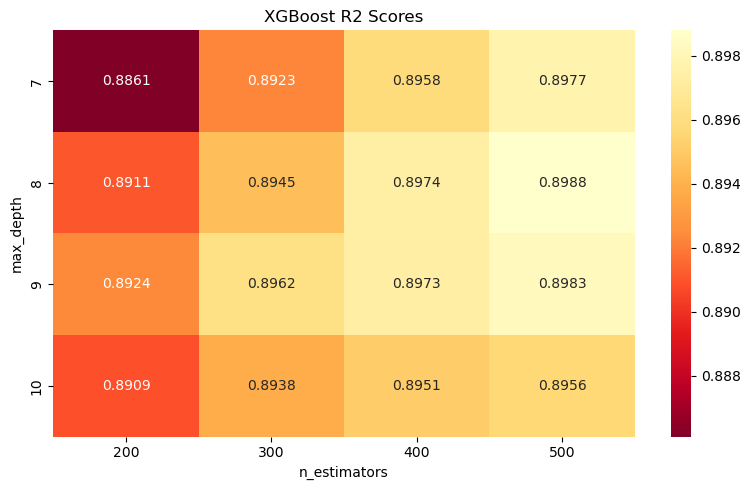

In [105]:
# R2 heatmap
heatmap_df = xgb_new_results.copy()

# convert metrics to float
heatmap_df['R2'] = heatmap_df['R2'].astype(float)
heatmap_df['MDAPE'] = heatmap_df['MDAPE'].str.strip('%').astype(float) / 100

pivot = heatmap_df.pivot(index='depth', columns='n_estimators', values='R2')

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd_r')
plt.title('XGBoost R2 Scores')
plt.xlabel('n_estimators')
plt.ylabel('max_depth')
plt.tight_layout()

## Install LightGBM

In [107]:
# %pip install lightgbm

In [108]:
from lightgbm import LGBMRegressor

## LightGBM Regressor

In [109]:
lgbm = LGBMRegressor(random_state=123, verbose=-1)
lgbm.fit(X_train, y_train)
lgbm_pred = lgbm.predict(X_test)

print(metrics(y_test, lgbm_pred))

{'R2': '0.8603', 'MAE': '$207336.68', 'RMSE': '$364275.77', 'MedianAbsoluteError': '$116149.47', 'MDAPE': '12.44%'}


In [124]:
# experiment to find optimal hyperparameters
lgbm_results = []

for depth in [7, 8, 9, 10]:
    for lr in [0.1, 0.2, 0.3]:
        for estimators in [300, 400, 500, 800, 1000]:

            # LightGBM model
            current_model = LGBMRegressor(
                random_state=123,
                max_depth=depth,
                learning_rate=lr,
                n_estimators=estimators
            )
            
            current_model.fit(X_train, y_train)
            pred = current_model.predict(X_test)
            m = metrics(y_test, pred)
    
            # update results
            current_result = {
                'depth': depth,
                'learning_rate': lr,
                'n_estimators': estimators
            }
            
            current_result.update(m)
            lgbm_results.append(current_result)


In [125]:
lgbm_results = pd.DataFrame(lgbm_results)
lgbm_results.sort_values(by=['R2', 'MDAPE'], ascending=[False, True]).head()

,depth,learning_rate,n_estimators,R2,MAE,RMSE,MedianAbsoluteError,MDAPE
39,9,0.2,1000,0.9047,$160612.56,$300871.88,$79023.08,8.76%
9,7,0.2,1000,0.9047,$161400.61,$300811.22,$80624.27,8.85%
24,8,0.2,1000,0.9042,$161077.87,$301624.53,$79796.83,8.82%
38,9,0.2,800,0.9034,$162737.36,$302973.75,$81096.39,8.92%
59,10,0.3,1000,0.9033,$162289.30,$303086.21,$80435.50,8.89%


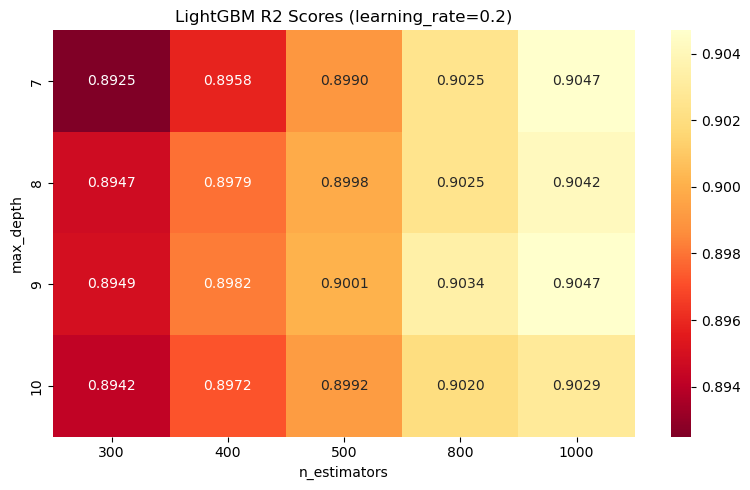

In [126]:
# R2 heatmap
heatmap_lgbm = lgbm_results.copy()
heatmap_lgbm = heatmap_lgbm[heatmap_lgbm['learning_rate'] == 0.2]

# convert metrics to float
heatmap_lgbm['R2'] = heatmap_lgbm['R2'].astype(float)
heatmap_lgbm['MDAPE'] = heatmap_lgbm['MDAPE'].str.strip('%').astype(float) / 100

lgbm_pivot = heatmap_lgbm.pivot(index='depth', columns='n_estimators', values='R2')

plt.figure(figsize=(8, 5))
sns.heatmap(lgbm_pivot, annot=True, fmt='.4f', cmap='YlOrRd_r')
plt.title('LightGBM R2 Scores (learning_rate=0.2)')
plt.xlabel('n_estimators')
plt.ylabel('max_depth')
plt.tight_layout()